In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN DE RUTAS ---
directorio_actual = os.getcwd()
if directorio_actual.endswith("notebooks"):
    os.chdir("..")

CSV_PATH = os.path.join("data", "measurements.csv")
REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)

# --- 2. LECTURA Y LIMPIEZA DE DATOS ---
print(f"Leyendo datos desde '{CSV_PATH}'...\n")
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# Dividimos los datos según tu archivo
df_part_a = df[df['Experiment'] == 'Part_A'].copy()
df_part_b = df[df['Experiment'] == 'Part_B'].copy()

print("✅ Datos cargados y listos para graficar.")

Leyendo datos desde 'data\measurements.csv'...

✅ Datos cargados y listos para graficar.


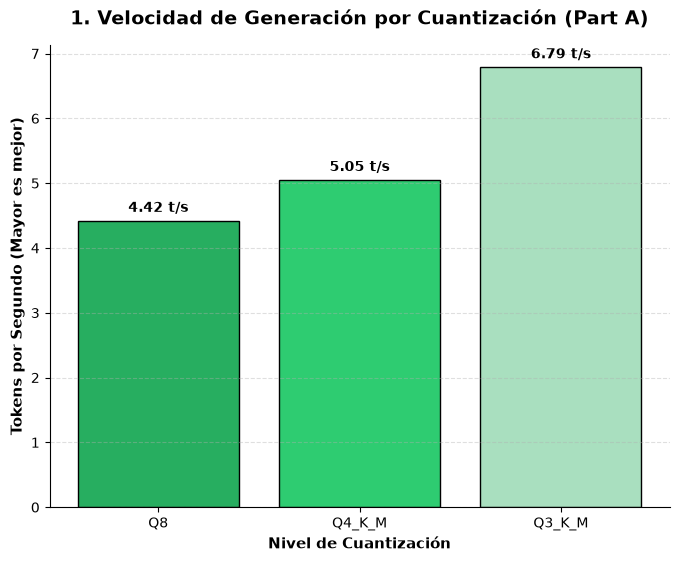

In [12]:
# --- GRÁFICO 1: VELOCIDAD (Tokens por Segundo) - Part A ---
plt.figure(figsize=(8, 6))
ax1 = plt.bar(df_part_a['Quantization'], df_part_a['Tokens_per_Sec'], color=['#27ae60', '#2ecc71', '#a9dfbf'], edgecolor='black')
plt.title('1. Velocidad de Generación por Cuantización (Part A)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Tokens por Segundo (Mayor es mejor)', fontsize=11, fontweight='bold')
plt.xlabel('Nivel de Cuantización', fontsize=11, fontweight='bold')

for p in ax1:
    altura = p.get_height()
    plt.annotate(f"{altura:.2f} t/s", (p.get_x() + p.get_width() / 2., altura),
                 ha='center', va='bottom', fontweight='bold', xytext=(0, 4), textcoords='offset points')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Guardar y MOSTRAR
plt.savefig(os.path.join(REPORT_DIR, "1_velocidad_tokens.png"), dpi=300, bbox_inches='tight')
plt.show()

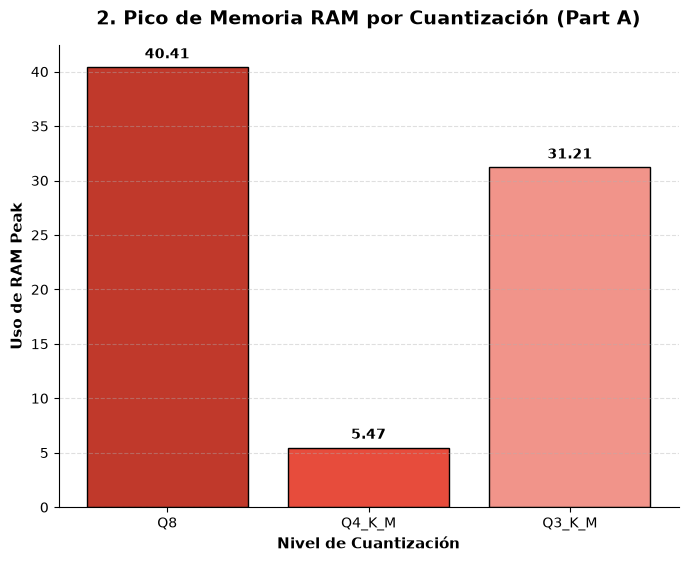

In [13]:
# --- GRÁFICO 2: PICO DE RAM POR MODELO - Part A ---
plt.figure(figsize=(8, 6))
ax2 = plt.bar(df_part_a['Quantization'], df_part_a['RAM_MB_Peak'], color=['#c0392b', '#e74c3c', '#f1948a'], edgecolor='black')
plt.title('2. Pico de Memoria RAM por Cuantización (Part A)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Uso de RAM Peak', fontsize=11, fontweight='bold')
plt.xlabel('Nivel de Cuantización', fontsize=11, fontweight='bold')

for p in ax2:
    altura = p.get_height()
    plt.annotate(f"{altura:.2f}", (p.get_x() + p.get_width() / 2., altura),
                 ha='center', va='bottom', fontweight='bold', xytext=(0, 4), textcoords='offset points')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Guardar y MOSTRAR
plt.savefig(os.path.join(REPORT_DIR, "2_consumo_ram.png"), dpi=300, bbox_inches='tight')
plt.show()

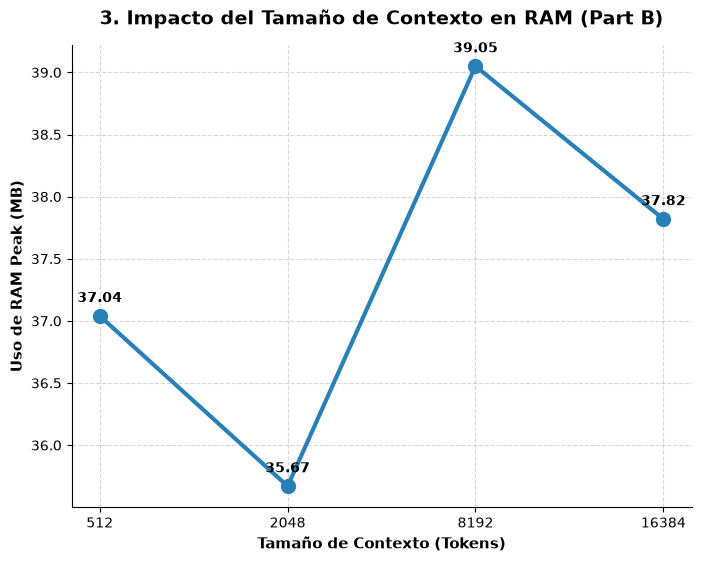

In [14]:
# --- GRÁFICO 3: IMPACTO DEL CONTEXTO EN LA RAM - Part B ---
plt.figure(figsize=(8, 6))

contextos_str = df_part_b['Context_Size'].astype(str)
plt.plot(contextos_str, df_part_b['RAM_MB_Peak'], marker='o', markersize=10, color='#2980b9', linewidth=3)

plt.title('3. Impacto del Tamaño de Contexto en RAM (Part B)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Uso de RAM Peak (MB)', fontsize=11, fontweight='bold')
plt.xlabel('Tamaño de Contexto (Tokens)', fontsize=11, fontweight='bold')

for x, y in zip(contextos_str, df_part_b['RAM_MB_Peak']):
    plt.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.5)

# Guardar y MOSTRAR
plt.savefig(os.path.join(REPORT_DIR, "3_impacto_contexto.png"), dpi=300, bbox_inches='tight')
plt.show()

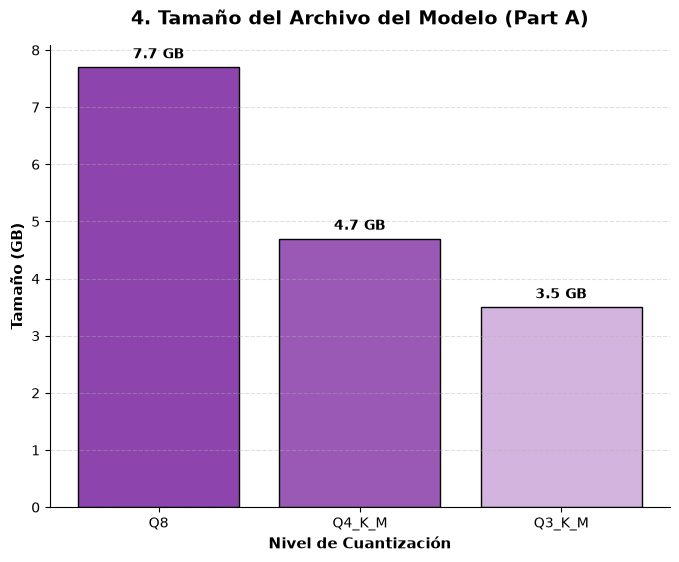

In [15]:
# --- GRÁFICO 4: TAMAÑO DEL ARCHIVO - Part A ---
plt.figure(figsize=(8, 6))
ax4 = plt.bar(df_part_a['Quantization'], df_part_a['File_Size_GB'], color=['#8e44ad', '#9b59b6', '#d2b4de'], edgecolor='black')
plt.title('4. Tamaño del Archivo del Modelo (Part A)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Tamaño (GB)', fontsize=11, fontweight='bold')
plt.xlabel('Nivel de Cuantización', fontsize=11, fontweight='bold')

for p in ax4:
    altura = p.get_height()
    plt.annotate(f"{altura:.1f} GB", (p.get_x() + p.get_width() / 2., altura),
                 ha='center', va='bottom', fontweight='bold', xytext=(0, 4), textcoords='offset points')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Guardar y MOSTRAR
plt.savefig(os.path.join(REPORT_DIR, "4_tamano_archivo.png"), dpi=300, bbox_inches='tight')
plt.show()

Leyendo evaluación desde 'data\eval_results.json'...



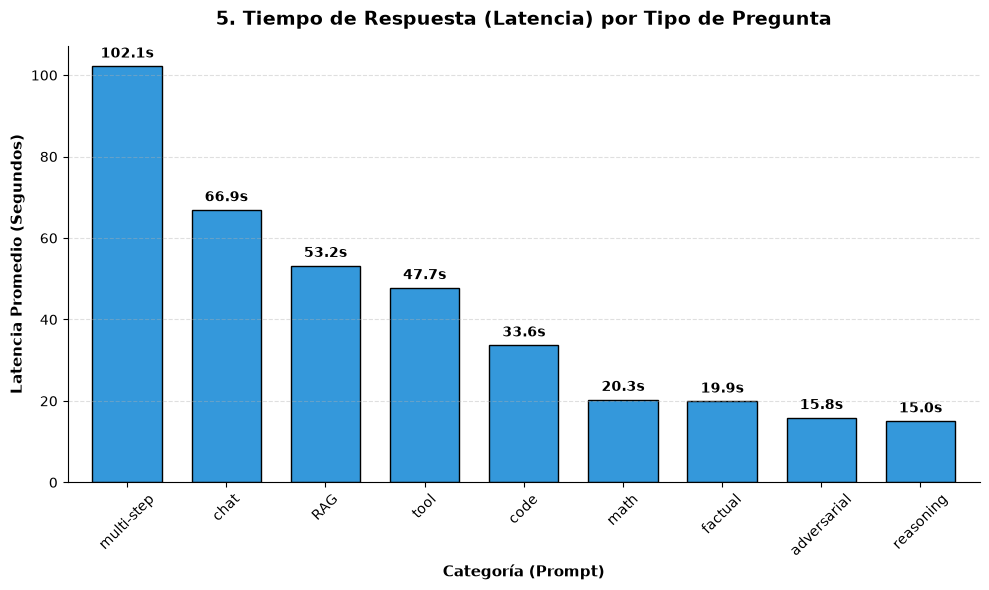

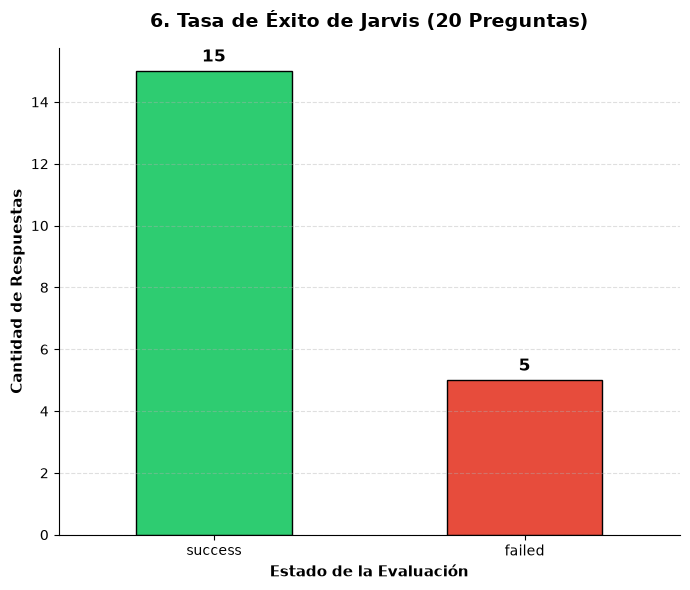

✅ ¡Gráficos de las 20 preguntas generados exitosamente!


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# --- 1. CONFIGURACIÓN SEGURA DE RUTAS ---
# Esta línea evita que Jupyter se pierda si corres la celda varias veces
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# AQUÍ ESTABA EL ERROR: Le decimos que busque adentro de la carpeta 'data'
JSON_PATH = os.path.join("data", "eval_results.json")
REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)

# --- 2. LECTURA DEL JSON DE LAS 20 PREGUNTAS ---
print(f"Leyendo evaluación desde '{JSON_PATH}'...\n")

try:
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        datos_eval = json.load(f)

    # Convertir el JSON a un DataFrame de pandas
    df_eval = pd.DataFrame(datos_eval)

    # --- GRÁFICO 5: LATENCIA POR CATEGORÍA DE PREGUNTA ---
    plt.figure(figsize=(10, 6))
    # Agrupar por categoría y sacar el promedio de latencia
    latencia_cat = df_eval.groupby('category')['latency'].mean().sort_values(ascending=False)

    ax5 = latencia_cat.plot(kind='bar', color='#3498db', edgecolor='black', width=0.7)
    plt.title('5. Tiempo de Respuesta (Latencia) por Tipo de Pregunta', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Latencia Promedio (Segundos)', fontsize=11, fontweight='bold')
    plt.xlabel('Categoría (Prompt)', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45)

    for p in ax5.patches:
        ax5.annotate(f"{p.get_height():.1f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', xytext=(0, 4), textcoords='offset points')

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    # Guardar y MOSTRAR
    plt.savefig(os.path.join(REPORT_DIR, "5_latencia_preguntas.png"), dpi=300)
    plt.show()

    # --- GRÁFICO 6: TASA DE ÉXITO (SUCCESS VS FAILED) ---
    plt.figure(figsize=(7, 6))

    conteo_exito = df_eval['success'].value_counts()
    # Colores: Verde para success, Rojo para failed
    colores = ['#2ecc71' if estado == 'success' else '#e74c3c' for estado in conteo_exito.index]

    ax6 = conteo_exito.plot(kind='bar', color=colores, edgecolor='black', width=0.5)
    plt.title('6. Tasa de Éxito de Jarvis (20 Preguntas)', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Cantidad de Respuestas', fontsize=11, fontweight='bold')
    plt.xlabel('Estado de la Evaluación', fontsize=11, fontweight='bold')
    plt.xticks(rotation=0)

    for p in ax6.patches:
        ax6.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=12, xytext=(0, 4), textcoords='offset points')

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    # Guardar y MOSTRAR
    plt.savefig(os.path.join(REPORT_DIR, "6_tasa_exito.png"), dpi=300)
    plt.show()

    print("✅ ¡Gráficos de las 20 preguntas generados exitosamente!")

except FileNotFoundError:
    print(f"❌ Error: Aún no encuentro el archivo en '{JSON_PATH}'.")